In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

main = pd.read_csv('../data/processed/ethiopia_fi_enriched_main.csv', parse_dates=['observation_date'])
main['observation_date'] = pd.to_datetime(main['observation_date'], errors='coerce')
impact = pd.read_csv('../data/processed/ethiopia_fi_enriched_impact.csv')

obs = main[main['record_type'] == 'observation'].copy()
events = main[main['record_type'] == 'event'].copy()

print(main.shape, obs.shape, events.shape)
obs[['indicator_code','value_numeric','observation_date']].sort_values('observation_date').head(10)

(45, 34) (31, 34) (11, 34)


,indicator_code,value_numeric,observation_date
0,ACC_OWNERSHIP,22.0,2014-12-31
1,ACC_OWNERSHIP,35.0,2017-12-31
2,ACC_OWNERSHIP,46.0,2021-12-31
3,ACC_OWNERSHIP,56.0,2021-12-31
4,ACC_OWNERSHIP,36.0,2021-12-31
26,GEN_GAP_ACC,20.0,2021-12-31
6,ACC_MM_ACCOUNT,4.7,2021-12-31
8,ACC_4G_COV,37.5,2023-06-30
14,USG_P2P_COUNT,49700000.0,2024-07-07
11,ACC_FAYDA,8000000.0,2024-08-15


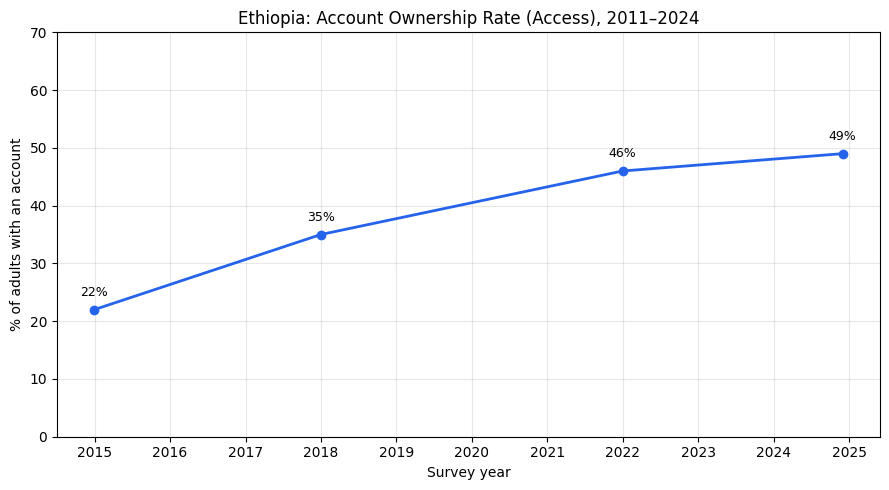

  observation_date  value_numeric  pp_change  pp_per_year
0       2014-12-31           22.0        NaN          NaN
1       2017-12-31           35.0       13.0     4.333333
2       2021-12-31           46.0       11.0     2.750000
5       2024-11-29           49.0        3.0     1.000000


In [7]:
acc_national = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'] == 'all')].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(acc_national['observation_date'], acc_national['value_numeric'], marker='o', linewidth=2, color='#2563eb')
for _, row in acc_national.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

ax.set_title("Ethiopia: Account Ownership Rate (Access), 2011–2024")
ax.set_ylabel("% of adults with an account")
ax.set_xlabel("Survey year")
ax.set_ylim(0, 70)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/access_trajectory.png', dpi=150)
plt.show()

# Growth rates between survey years
acc_national['pp_change'] = acc_national['value_numeric'].diff()
acc_national['years_elapsed'] = acc_national['observation_date'].dt.year.diff()
acc_national['pp_per_year'] = acc_national['pp_change'] / acc_national['years_elapsed']
print(acc_national[['observation_date','value_numeric','pp_change','pp_per_year']])

In [9]:
gender_2021 = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'].isin(['male','female']))].sort_values('observation_date')
print(gender_2021[['observation_date','gender','value_numeric']])

gap = gender_2021.pivot(index='observation_date', columns='gender', values='value_numeric')
gap['gap_pp'] = gap['male'] - gap['female']
print("\nGender gap (pp):\n", gap)

# Also check the GEN_GAP_ACC indicator directly if it tracks this over time
gen_gap_obs = obs[obs['indicator_code'] == 'GEN_GAP_ACC'].sort_values('observation_date')
print("\nGEN_GAP_ACC indicator over time:\n", gen_gap_obs[['observation_date','value_numeric','gender']])

  observation_date  gender  value_numeric
3       2021-12-31    male           56.0
4       2021-12-31  female           36.0

Gender gap (pp):
 gender            female  male  gap_pp
observation_date                      
2021-12-31          36.0  56.0    20.0

GEN_GAP_ACC indicator over time:
    observation_date  value_numeric gender
26       2021-12-31           20.0    all
27       2024-11-29           18.0    all


In [10]:
usage_indicators = ['ACC_MM_ACCOUNT', 'USG_TELEBIRR_USERS', 'USG_MPESA_USERS', 'USG_P2P_COUNT', 'USG_ATM_COUNT', 'USG_CROSSOVER', 'USG_ACTIVE_RATE']
usage_obs = obs[obs['indicator_code'].isin(usage_indicators)].sort_values('observation_date')
print(usage_obs[['observation_date','indicator_code','value_numeric','unit']].to_string(index=False))

observation_date     indicator_code  value_numeric         unit
      2021-12-31     ACC_MM_ACCOUNT           4.70            %
      2024-07-07      USG_P2P_COUNT    49700000.00 transactions
      2024-11-29     ACC_MM_ACCOUNT           9.45            %
      2024-12-31    USG_MPESA_USERS    10800000.00        users
      2024-12-31    USG_ACTIVE_RATE          66.00            %
      2025-06-30 USG_TELEBIRR_USERS    54840000.00        users
      2025-07-07      USG_P2P_COUNT   128300000.00 transactions
      2025-07-07      USG_ATM_COUNT   119300000.00 transactions
      2025-07-07      USG_CROSSOVER           1.08        ratio


In [11]:
infra_indicators = ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'AFF_DATA_INCOME']
infra_obs = obs[obs['indicator_code'].isin(infra_indicators)].sort_values('observation_date')
print(infra_obs[['observation_date','indicator_code','value_numeric','unit']].to_string(index=False))

observation_date  indicator_code  value_numeric     unit
      2023-06-30      ACC_4G_COV           37.5        %
      2024-12-31 AFF_DATA_INCOME            2.0 % of GNI
      2025-06-30      ACC_4G_COV           70.8        %
      2025-12-31  ACC_MOBILE_PEN           61.4        %


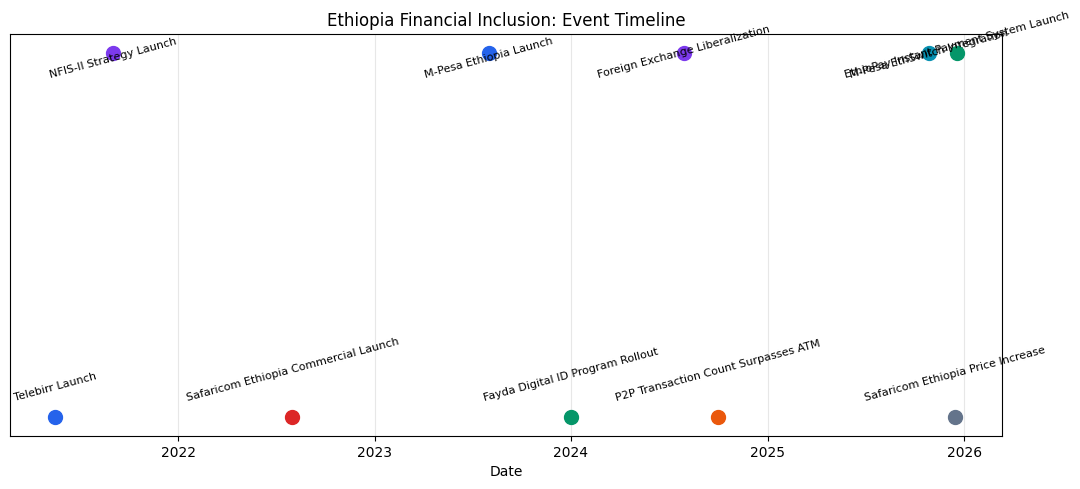

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
events_sorted = events.sort_values('observation_date')
colors = {'product_launch':'#2563eb','market_entry':'#dc2626','infrastructure':'#059669',
          'policy':'#7c3aed','milestone':'#ea580c','partnership':'#0891b2','pricing':'#64748b','regulation':'#be185d'}

for i, (_, row) in enumerate(events_sorted.iterrows()):
    y = i % 2
    ax.scatter(row['observation_date'], y, color=colors.get(row['category'],'gray'), s=100, zorder=3)
    ax.annotate(row['indicator'], (row['observation_date'], y), textcoords="offset points",
                xytext=(0, 12 if y==0 else -18), ha='center', fontsize=8, rotation=15)

ax.set_yticks([])
ax.set_title("Ethiopia Financial Inclusion: Event Timeline")
ax.set_xlabel("Date")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/event_timeline.png', dpi=150)
plt.show()

Events dropped due to bad dates: 1


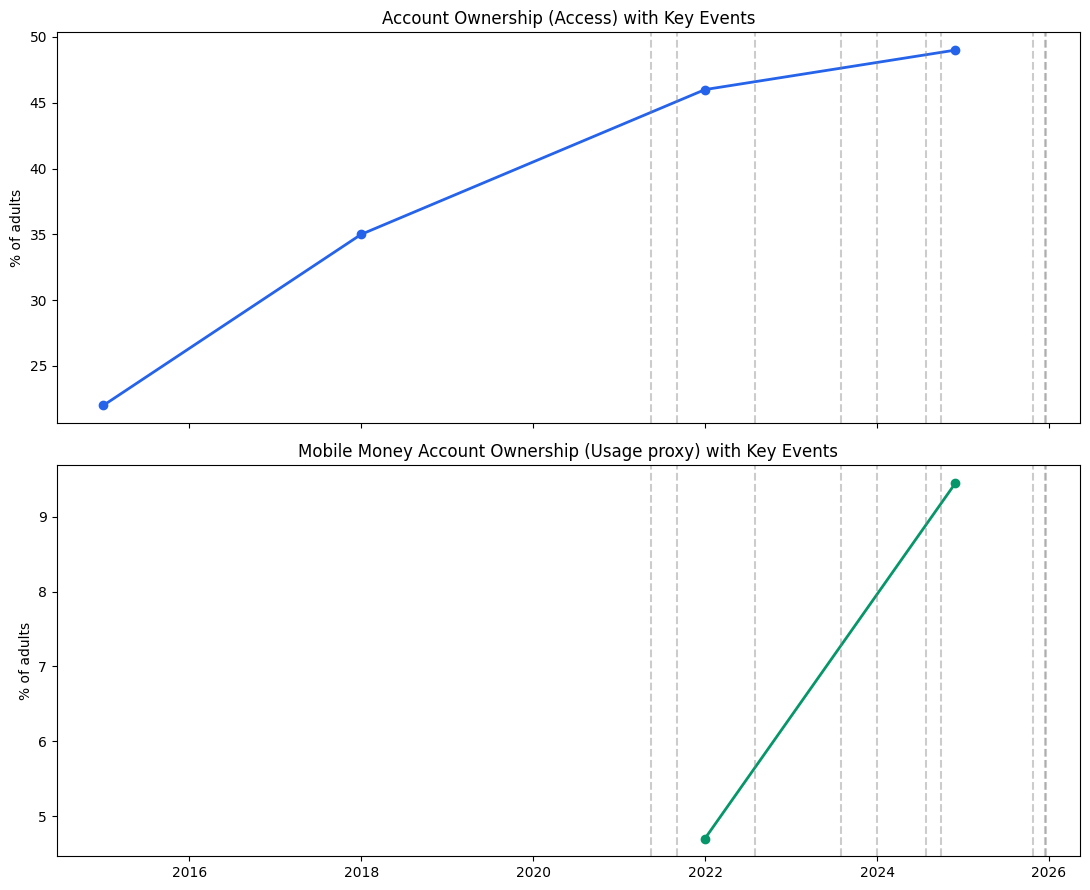

In [16]:
# Ensure dates are proper datetimes everywhere
events['observation_date'] = pd.to_datetime(events['observation_date'], errors='coerce')
events_sorted = events.sort_values('observation_date').dropna(subset=['observation_date'])

print("Events dropped due to bad dates:", events['observation_date'].isna().sum())

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

axes[0].plot(acc_national['observation_date'], acc_national['value_numeric'], marker='o', color='#2563eb', linewidth=2)
axes[0].set_title("Account Ownership (Access) with Key Events")
axes[0].set_ylabel("% of adults")

mm = obs[obs['indicator_code']=='ACC_MM_ACCOUNT'].sort_values('observation_date')
axes[1].plot(mm['observation_date'], mm['value_numeric'], marker='o', color='#059669', linewidth=2)
axes[1].set_title("Mobile Money Account Ownership (Usage proxy) with Key Events")
axes[1].set_ylabel("% of adults")

for ax in axes:
    for _, ev in events_sorted.iterrows():
        ax.axvline(ev['observation_date'], color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/figures/access_usage_events_overlay.png', dpi=150)
plt.show()

In [17]:
main_check = main[main['record_type']=='event'].copy()
main_check['parsed'] = pd.to_datetime(main_check['observation_date'], errors='coerce')
print(main_check[main_check['parsed'].isna()][['record_id','indicator','observation_date']])

   record_id                              indicator observation_date
44  EVT_0011  Fayda Mandatory for Banking Directive              NaT


In [14]:
key_codes = ['ACC_OWNERSHIP','ACC_MM_ACCOUNT','ACC_4G_COV','USG_P2P_COUNT','USG_CROSSOVER','USG_ACTIVE_RATE']
wide = obs[obs['indicator_code'].isin(key_codes) & (obs['gender']=='all' if 'gender' in obs.columns else True)]
pivot = wide.pivot_table(index='observation_date', columns='indicator_code', values='value_numeric')
print("Data points per indicator (sparse — correlation is indicative only):\n", pivot.count())
print("\nCorrelation matrix:\n", pivot.corr().round(2))

Data points per indicator (sparse — correlation is indicative only):
 indicator_code
ACC_4G_COV         2
ACC_MM_ACCOUNT     2
ACC_OWNERSHIP      4
USG_ACTIVE_RATE    1
USG_CROSSOVER      1
USG_P2P_COUNT      2
dtype: int64

Correlation matrix:
 indicator_code   ACC_4G_COV  ACC_MM_ACCOUNT  ACC_OWNERSHIP  USG_ACTIVE_RATE  \
indicator_code                                                                
ACC_4G_COV              1.0             NaN            NaN              NaN   
ACC_MM_ACCOUNT          NaN             1.0            1.0              NaN   
ACC_OWNERSHIP           NaN             1.0            1.0              NaN   
USG_ACTIVE_RATE         NaN             NaN            NaN              NaN   
USG_CROSSOVER           NaN             NaN            NaN              NaN   
USG_P2P_COUNT           NaN             NaN            NaN              NaN   

indicator_code   USG_CROSSOVER  USG_P2P_COUNT  
indicator_code                                 
ACC_4G_COV               

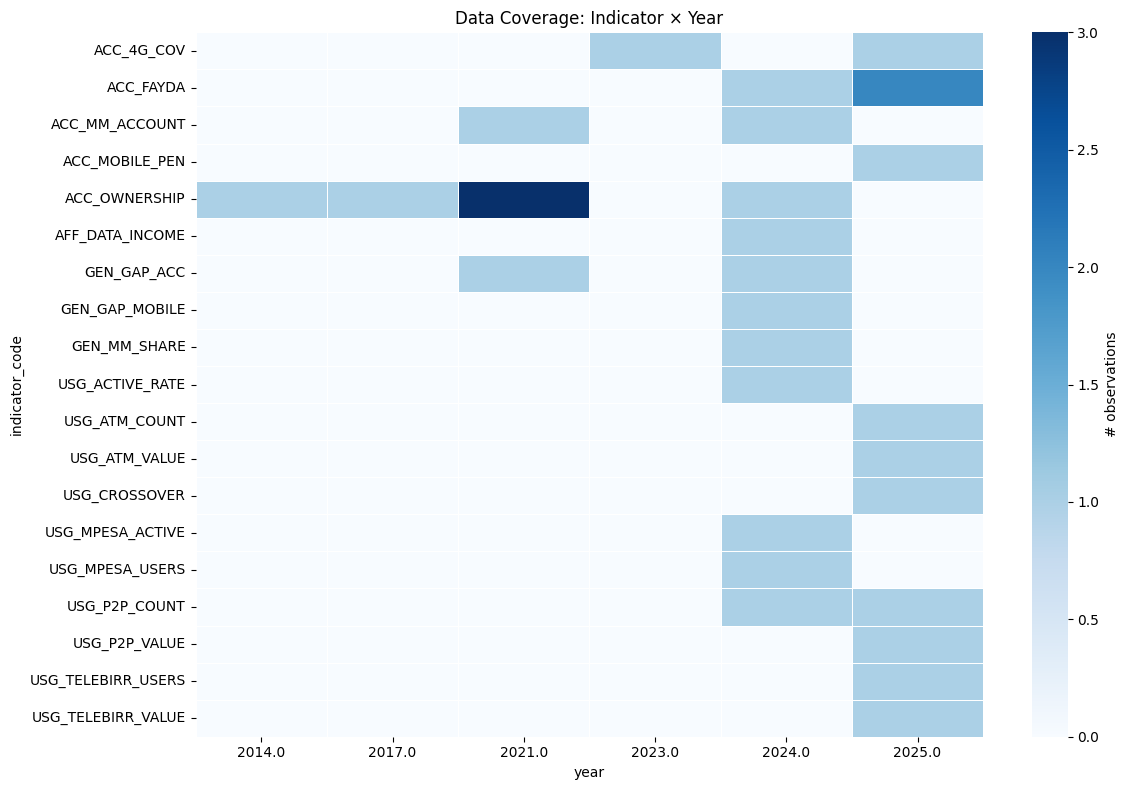


Confidence distribution:
 confidence
high      28
medium     3
Name: count, dtype: int64

Source type distribution:
 source_type
operator      11
survey        10
research       4
regulator      3
calculated     2
news           1
Name: count, dtype: int64


In [15]:
obs['year'] = obs['observation_date'].dt.year
coverage = obs.pivot_table(index='indicator_code', columns='year', values='value_numeric', aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(coverage, cmap='Blues', cbar_kws={'label':'# observations'}, linewidths=0.5, ax=ax)
ax.set_title("Data Coverage: Indicator × Year")
plt.tight_layout()
plt.savefig('../reports/figures/data_coverage_heatmap.png', dpi=150)
plt.show()

print("\nConfidence distribution:\n", obs['confidence'].value_counts())
print("\nSource type distribution:\n", obs['source_type'].value_counts())

## Key EDA Insights

1. **Access growth is decelerating sharply.** Account ownership grew +13pp (2014–17, 4.33pp/yr) → +11pp (2017–21, 2.75pp/yr) → +3pp (2021–24, only 1.0pp/yr) — a 4x slowdown in the pace of inclusion despite Telebirr and M-Pesa both launching in this window.

2. **Mobile money growth hasn't translated into account ownership growth.** Mobile money account ownership roughly doubled (4.7% → 9.45%, 2021–2024), yet national account ownership rose only 3pp in the same period. This suggests most new mobile money users are converting *existing* bank account holders to omnichannel usage, not pulling in previously unbanked adults — consistent with Ethiopia's low mobile-money-only user rate (~0.5%).

3. **The gender gap is large and barely closing.** Male ownership (56%) vs. female (36%) in 2021 is a 20pp gap; the GEN_GAP_ACC indicator only narrowed to 18pp by 2024 — a 2pp improvement over 3 years, far too slow to close given the overall access stagnation.

4. **P2P has overtaken ATM cash withdrawals.** By mid-2025, P2P transaction count (128.3M) exceeded ATM transactions (119.3M) — crossover ratio of 1.08 — while both P2P and ATM volumes are still growing, evidencing genuine channel shift, not just decline of one channel.

5. **Infrastructure is scaling faster than adoption.** 4G population coverage nearly doubled (37.5% → 70.8%, 2023–2025) and mobile penetration reached 61.4% by end-2025, yet these enabler gains haven't yet shown up as commensurate account ownership growth — a leading-indicator lag worth flagging for the forecast model.

6. **Data quality/coverage limitation:** correlation analysis is only indicative — most indicators have just 1–4 data points, so correlations (e.g., ACC_MM_ACCOUNT vs ACC_OWNERSHIP at r=1.0) reflect only 2 shared time points and shouldn't be over-interpreted as causal or statistically robust.

7. **Hypothesis for Task 3:** the 2021–24 slowdown coincides with mobile money and Telebirr scaling, suggesting these products serve the *already-banked* more than the unbanked — a hypothesis to test via impact_link modeling and comparable-country M-Pesa evidence.